_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: <span style='background: yellow'>*FILL IN YOUR NAMES HERE* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span>

# Coding Lab 4

In this notebook you will work with preprocessed 2 photon calcium recordings, that have already been converted into spike counts for a population of cells from the Macaque V1. During the experiment the animal has been presented with several drifting grating stimuli, in response to which the neural activity was recorded. In this exercise sheet we will study how you can visualize the activity of multiple neural spike trains and assess whether a neuron is selective to a specific stimulus type.

Download the data files ```nds_cl_4_*.csv``` from ILIAS and save it in the subfolder ```../data/```. We recommend you to use a subset of the data for testing and debugging, ideally focus on a single cell (e.g. cell number x). The spike times and stimulus conditions are read in as pandas data frames. You can solve the exercise by making heavy use of that, allowing for many quite compact computations. See [documentation](http://pandas.pydata.org/pandas-docs/stable/index.html) and several good [tutorials](https://www.datacamp.com/community/tutorials/pandas-tutorial-dataframe-python#gs.L37i87A) on how to do this. Of course, converting the data into classical numpy arrays is also valid.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.optimize as opt

from scipy import signal as signal
from typing import Tuple

import itertools

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2025-05-15 19:29:16CEST

Python implementation: CPython
Python version       : 3.9.6
IPython version      : 8.18.1

sklearn: 1.5.2

pandas    : 2.2.3
seaborn   : 0.13.2
numpy     : 2.0.2
matplotlib: 3.9.2
scipy     : 1.13.1

Watermark: 2.5.0



In [3]:
plt.style.use("../matplotlib_style.txt")

## Load data

In [4]:
spikes = pd.read_csv("../data/nds_cl_4_spiketimes.csv")  # neuron id, spike time
stims = pd.read_csv("../data/nds_cl_4_stimulus.csv")  # stimulus onset in ms, direction

stimDur = 2000.0  # in ms
nTrials = 11  # number of trials per condition
nDirs = 16  # number of conditions
deltaDir = 22.5  # difference between conditions

stims["StimOffset"] = stims["StimOnset"] + stimDur

We require some more information about the spikes for the plots and analyses we intend to make later. With a solution based on dataframes, it is natural to compute this information here and add it as additional columns to the `spikes` dataframe by combining it with the `stims` dataframe. We later need to know which condition (`Dir`) and trial (`Trial`) a spike was recorded in, the relative spike times compared to stimulus onset of the stimulus it was recorded in (`relTime`) and whether a spike was during the stimulation period (`stimPeriod`). But there are many options how to solve this exercise and you are free to choose any of them.

In [5]:
# you may add computations as specified above
spikes["Dir"] = np.nan
spikes["relTime"] = np.nan
spikes["Trial"] = np.nan
spikes["stimPeriod"] = np.nan
spikes["stimPeriod"] = spikes["stimPeriod"].astype(bool)

dirs = np.unique(stims["Dir"])
trialcounter = np.zeros_like(dirs)

for i, row in stims.iterrows():

    trialcounter[dirs == row["Dir"]] += 1

    i0 = spikes["SpikeTimes"] > row["StimOnset"]
    i1 = spikes["SpikeTimes"] < row["StimOffset"]

    select = i0.values & i1.values

    spikes.loc[select, "Dir"] = row["Dir"]
    spikes.loc[select, "Trial"] = trialcounter[dirs == row["Dir"]][0]
    spikes.loc[select, "relTime"] = spikes.loc[select, "SpikeTimes"] - row["StimOnset"]
    spikes.loc[select, "stimPeriod"] = True

spikes = spikes.dropna()

## Task 1: Plot spike rasters

In a raster plot, each spike is shown by a small tick at the time it occurs relative to stimulus onset. Implement a function `plotRaster()` that plots the spikes of one cell as one trial per row, sorted by conditions (similar to what you saw in the lecture). Why are there no spikes in some conditions and many in others?

If you opt for a solution without a dataframe, you need to change the interface of the function.

*Grading: 3 pts*


**Why are there no spikes in some conditions and many in others?**

This reflects the fact that some V1 neurons are direction‐selective. Each neuron has a preferred orientation/direction of motion: when the grating drifts in that preferred direction, the cell fires vigorously (many spikes), whereas motion in orthogonal or opposite directions fails to drive it, resulting in few or no spikes.

In [6]:
def plotRaster(spikes: pd.DataFrame, neuron: int, extra_title=""):
    """plot spike rasters for a single neuron sorted by condition

    Parameters
    ----------

    spikes: pd.DataFrame
        Pandas DataFrame with columns
            Neuron | SpikeTimes | Dir | relTime | Trial | stimPeriod

    neuron: int
        Neuron ID


    Note
    ----

    this function does not return anything, it just creates a plot!
    """

    # -------------------------------------------------
    # Write a raster plot function for the data (2 pts)
    # -------------------------------------------------

    # filter spikes for the specified neuron
    df = spikes[spikes["Neuron"] == neuron]

    # group by direction and trial, then sort by those keys
    sorted_groups = sorted(df.groupby(["Dir", "Trial"]), key=lambda x: x[0])
    spike_times = [group["relTime"].to_numpy() for _, group in sorted_groups]
    directions = [dir_ for (dir_, _), _ in sorted_groups]

    # create the raster
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    ax.eventplot(spike_times, linelengths=0.8)
    ax.set_xlabel("Time from stimulus onset (ms)")
    ax.set_title(f"Raster plot for neuron {neuron}" + extra_title)

    # draw separators where direction changes
    boundaries = [
        i - 0.5 for i in range(1, len(directions)) if directions[i] != directions[i - 1]
    ]
    for y in boundaries:
        ax.axhline(y=y, color="gray", linestyle="--", linewidth=0.5)

    # compute center positions for each direction block
    unique_dirs = sorted(set(directions))
    positions = []
    for ud in unique_dirs:
        first = directions.index(ud)
        last = len(directions) - 1 - directions[::-1].index(ud)
        positions.append((first + last) / 2)

    ax.set_yticks(positions)
    ax.set_yticklabels([f"{d:.1f}°" for d in unique_dirs])

    plt.show()

Find examples of 
1. a direction selective neuron
2. an orientation selective neuron 
3. neither

and explain your choices.

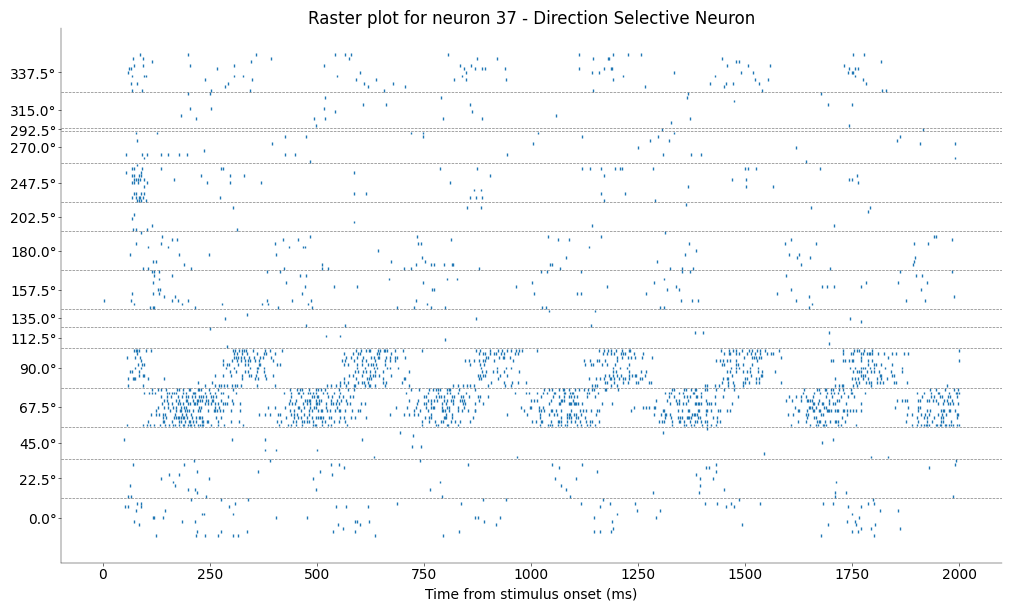

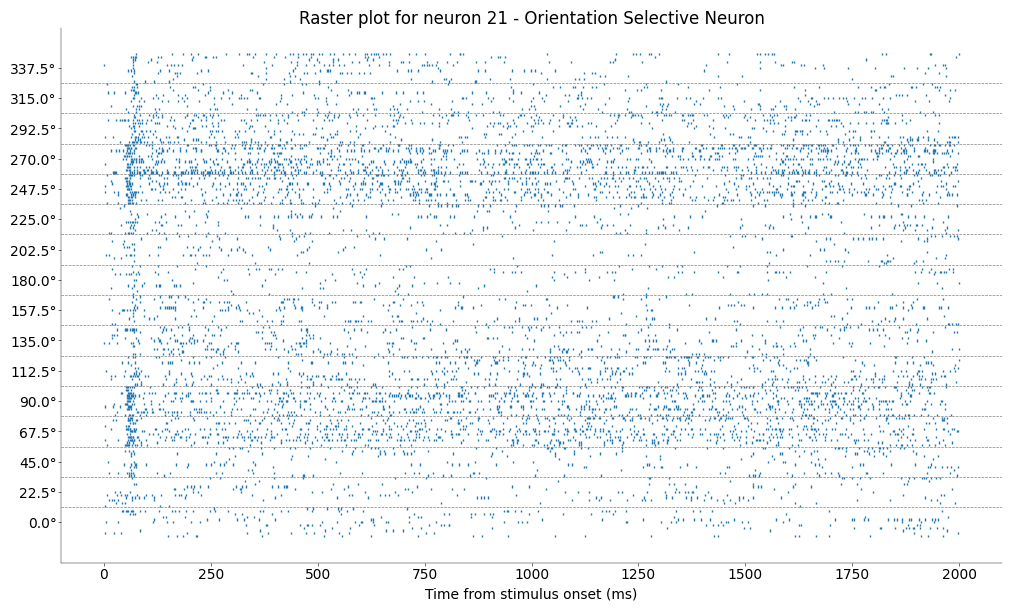

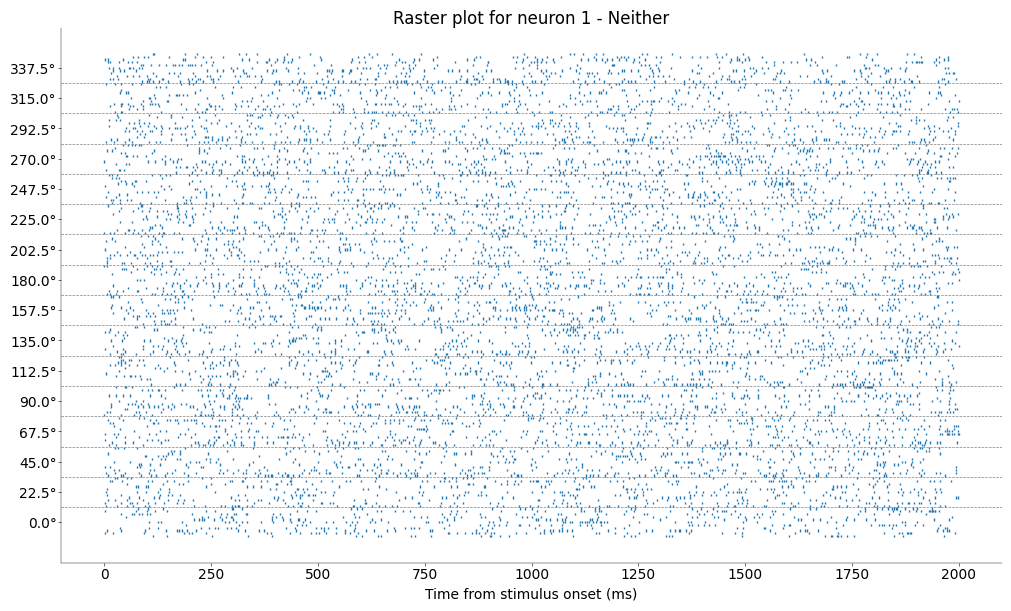

In [8]:
# ---------------------------------
# Find and explain examples? (1 pt)
# ---------------------------------
dir_sel_neuron = 37
orient_sel_neuron = 21
neither_neuron = 1

plotRaster(spikes, dir_sel_neuron, " - Direction Selective Neuron")
plotRaster(spikes, orient_sel_neuron, " - Orientation Selective Neuron")
plotRaster(spikes, neither_neuron, " - Neither")

**Neuron 37 – Direction‐Selective**
The raster shows a clear, solitary band of spikes when the grating drifts at ~67.5° (and nearby 90°), with almost no spiking when it drifts in the opposite direction (≈247.5°) or at any other angle. That one‐sided tuning—strong only for one motion vector—is the hallmark of direction selectivity.

**Neuron 21 – Orientation‐Selective**
This cell fires robustly for two directions exactly 180° apart (90° and 270°), but is nearly silent for all intervening angles. That symmetric, bimodal response (same rate for both opposite drift directions) tells you it cares about the axis of the grating, not the motion vector—classic orientation selectivity.

**Neuron 1 – Non-Selective**
The spikes for neuron 1 are sprinkled fairly evenly across all 16 direction blocks, with no discernible peak or trough. That flat, undifferentiated firing pattern indicates neither orientation nor direction tuning.



## Task 2: Plot spike density functions

Compute an estimate of the spike rate against time relative to stimulus onset. There are two ways:
* Discretize time: Decide on a bin size, count the spikes in each bin and average across trials. 
* Directly estimate the probability of spiking using a density estimator with specified kernel width. 

For full points, the optimal kernel- or bin-width needs to be computed.

Implement one of them in the function `plotPSTH()`. If you dont use a dataframe you may need to change the interface of the function.


*Grading: 4 pts*


In [9]:
def plotPSTH(spikes: pd.DataFrame, neuron: int, extra_title=""):
    """Plot PSTH for a single neuron sorted by condition

    Parameters
    ----------

    spikes: pd.DataFrame
        Pandas DataFrame with columns
            Neuron | SpikeTimes | Dir | relTime | Trial | stimPeriod

    neuron: int
        Neuron ID


    Note
    ----

    this function does not return anything, it just creates a plot!
    """

    # -------------------------------------------------
    # Implement one of the spike rate estimates (3 pts)
    # -------------------------------------------------

    df = spikes[spikes["Neuron"] == neuron].copy()

    # Find optimal bin_width per stimulus according to Shimazaki & Shinomoto 2007
    optimal_bin_widths = {}
    optimal_bin_edges = {}
    for d in np.sort(df["Dir"].unique()):
        sub = df[df["Dir"] == d]
        rel_times = sub["relTime"].values
        n_trials = sub["Trial"].nunique()

        costs_list = []
        deltas_list = []
        edges_list = []
        # scan over candidate numbers of bins
        for n_bins in range(2, 1000):
            edges = np.linspace(0.0, stimDur, n_bins + 1)
            delta = stimDur / n_bins
            counts, _ = np.histogram(rel_times, bins=edges)
            kbar = counts.mean()
            v = counts.var()
            cost = (2.0 * kbar - v) / (n_trials * delta) ** 2
            costs_list.append(cost)
            deltas_list.append(delta)
            edges_list.append(edges)

        # pick the delta with minimal cost for this direction
        optimal_bin_widths[d] = deltas_list[np.argmin(costs_list)]
        optimal_bin_edges[d] = edges_list[np.argmin(costs_list)]

    # sorted unique directions
    unique_dirs = np.sort(df["Dir"].unique())
    n_dirs = len(unique_dirs)

    fig, axes = plt.subplots(
        n_dirs, 1, sharex=True, figsize=(10, 6), constrained_layout=True
    )

    if n_dirs == 1:
        axes = [axes]

    # compute firing rates for each direction
    rates_list = []
    for d in unique_dirs:
        sub = df[df["Dir"] == d]
        trials = sub["Trial"].unique()
        counts_trials = []
        for t in trials:
            times = sub[sub["Trial"] == t]["relTime"].values
            counts, _ = np.histogram(times, bins=optimal_bin_edges[d])
            counts_trials.append(counts)
        mean_counts = np.mean(counts_trials, axis=0)
        rates_list.append(1000 * mean_counts / optimal_bin_widths[d])

    # global max for y-axis
    max_rate = max(r.max() for r in rates_list)

    for ax, d, r in zip(axes[::-1], unique_dirs, rates_list):
        ax.bar(optimal_bin_edges[d][:-1], r, width=optimal_bin_widths[d], align="edge")
        ax.set_ylim(0, max_rate * 1.1)
        ax.set_yticks([])
        # move the degree label further left by increasing labelpad
        ax.set_ylabel(f"{d:.1f}°", rotation=0, labelpad=20, va="center")

    axes[-1].set_xlabel("Time from stimulus onset (ms)")
    fig.suptitle(f"PSTH histograms for neuron {neuron}" + extra_title, y=1.02)
    plt.show()

Plot the same 3 examples you selected in Task 1

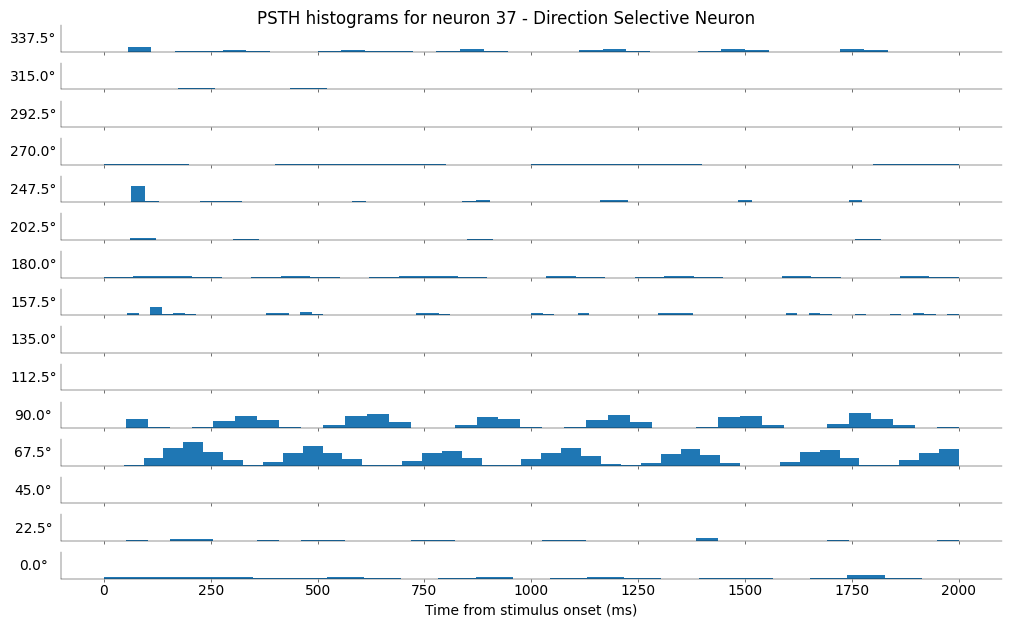

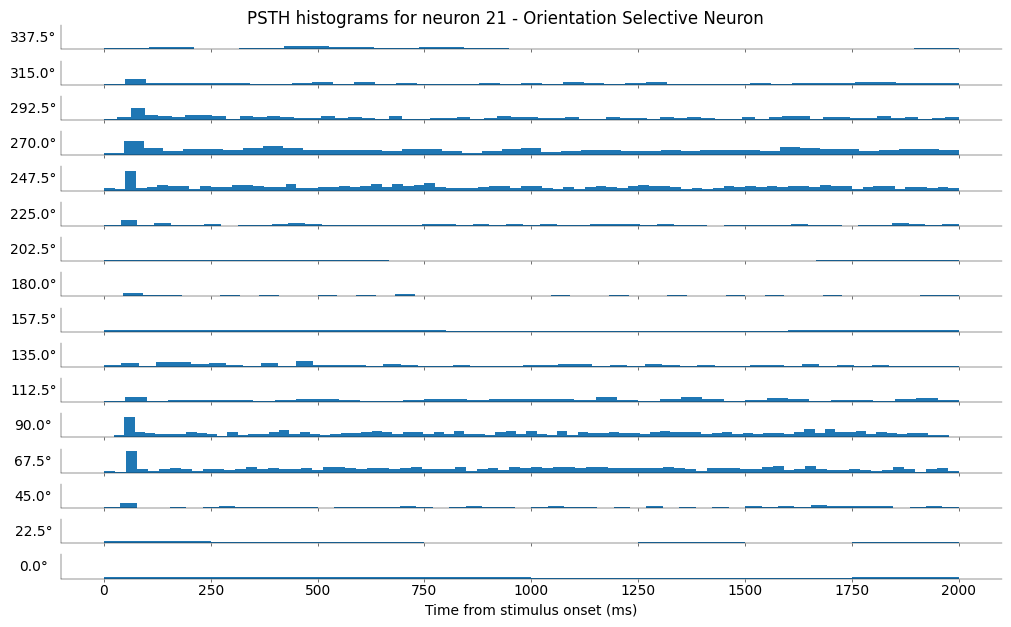

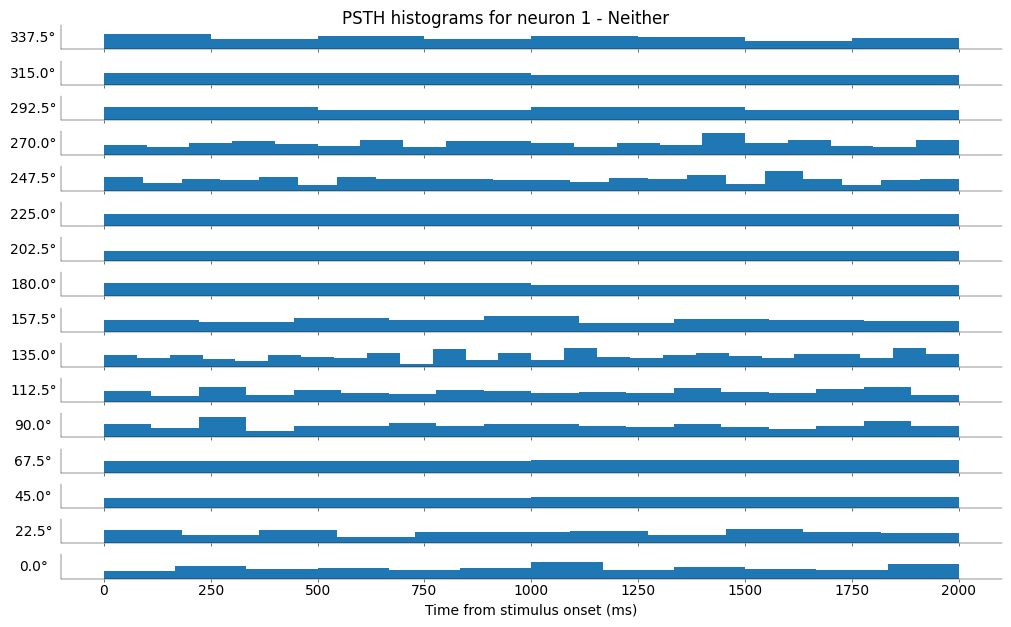

In [10]:
plotPSTH(spikes, dir_sel_neuron, " - Direction Selective Neuron")
plotPSTH(spikes, orient_sel_neuron, " - Orientation Selective Neuron")
plotPSTH(spikes, neither_neuron, " - Neither")

## Task 3: Fit and plot tuning functions

The goal is to visualize the activity of each neuron as a function of stimulus direction. First, compute the spike counts of each neuron for each direction of motion and trial.  The result should be a matrix `x`, where $x_{jk}$ represents the spike count of the $j$-th response to the $k$-th direction of motion (i.e. each column contains the spike counts for all trials with one direction of motion).	If you used dataframes above, the `groupby()` function allows to implement this very compactly. Make sure you don't loose trials with zero spikes though. Again, other implementations are completely fine.

Fit the tuning curve, i.e. the average spike count per direction, using a von Mises model. To capture the non-linearity and direction selectivity of the neurons, we will fit a modified von Mises function:

$$ f(\theta) = \exp(\alpha + \kappa (\cos (2*(\theta-\phi))-1) + \nu (\cos (\theta-\phi)-1))$$

Here, $\theta$ is the stimulus direction. Implement the von Mises function in `vonMises()` and plot it to understand how to interpret its parameters $\phi$, $\kappa$, $\nu$, $\alpha$. Perform a non-linear least squares fit using a package/function of your choice. Implement the fitting in `tuningCurve()`. 

Plot the average number of spikes per direction, the spike counts from individual trials as well as your optimal fit.

Select two cells that show nice tuning to test your code.

*Grading: 5 pts*

In [11]:
def vonMises(θ: np.ndarray, α: float, κ: float, ν: float, ϕ: float) -> np.ndarray:
    """Evaluate the parametric von Mises tuning curve with parameters p at locations theta.

    Parameters
    ----------

    θ: np.array, shape=(N, )
        Locations. The input unit is degree.

    α, κ, ν, ϕ : float
        Function parameters

    Return
    ------
    f: np.array, shape=(N, )
        Tuning curve.
    """

    # -----------------------------------
    # Implement the Mises model (0.5 pts)
    # -----------------------------------

    # convert degrees to radians
    θ = np.deg2rad(θ)
    ϕ = np.deg2rad(ϕ)

    # von Mises function
    f = np.exp(α + (κ * (np.cos(2 * (θ - ϕ)) - 1)) + (ν * (np.cos(θ - ϕ) - 1)))

    return f

Plot the von Mises function while varying the parameters systematically.

/var/folders/yf/pf3_bqj55n55b17z1ydbr5dc0000gn/T/ipykernel_98717/132646469.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0.02, 0, 1, 0.98])


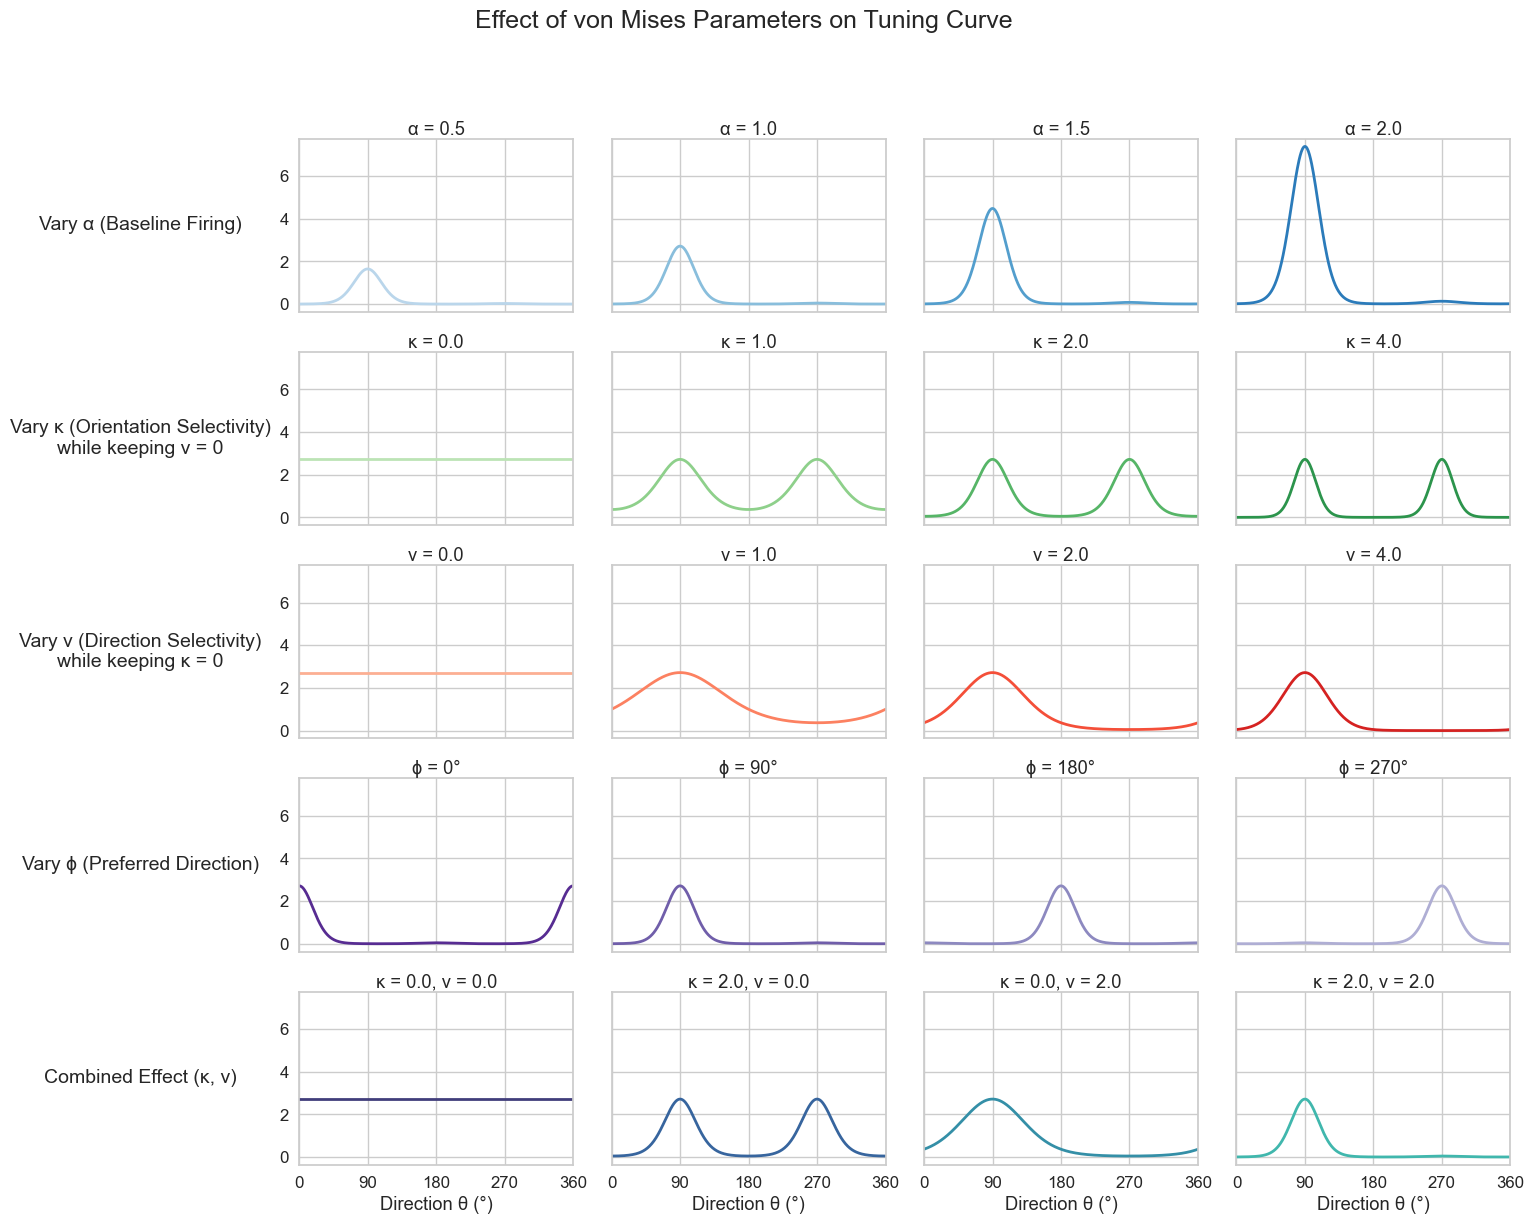

In [99]:
# ------------------------------------------------------------------------------
# plot von Mises curves with varying parameters and explain what they do (2 pts)
# ------------------------------------------------------------------------------

sns.set(style="whitegrid", font_scale=1.1)

θ_vals = np.linspace(0, 360, 500)
fig, axs = plt.subplots(5, 4, figsize=(16, 12), sharex=True, sharey=True)

# Row titles
row_labels = [
    "Vary α (Baseline Firing)",
    "Vary κ (Orientation Selectivity)\nwhile keeping ν = 0",
    "Vary ν (Direction Selectivity)\nwhile keeping κ = 0",
    "Vary ϕ (Preferred Direction)",
    "Combined Effect (κ, ν)",
]

# 1. α
alpha_values = [0.5, 1.0, 1.5, 2.0]
for i, α in enumerate(alpha_values):
    f = vonMises(θ_vals, α, κ=2.0, ν=2.0, ϕ=90)
    axs[0, i].plot(θ_vals, f, color=sns.color_palette("Blues")[i + 1], lw=2)
    axs[0, i].set_title(f"α = {α:.1f}")

# 2. κ
kappa_values = [0.0, 1.0, 2.0, 4.0]
for i, κ in enumerate(kappa_values):
    f = vonMises(θ_vals, α=1.0, κ=κ, ν=0.0, ϕ=90)
    axs[1, i].plot(θ_vals, f, color=sns.color_palette("Greens")[i + 1], lw=2)
    axs[1, i].set_title(f"κ = {κ:.1f}")

# 3. ν
nu_values = [0.0, 1.0, 2.0, 4.0]
for i, ν in enumerate(nu_values):
    f = vonMises(θ_vals, α=1.0, κ=0.0, ν=ν, ϕ=90)
    axs[2, i].plot(θ_vals, f, color=sns.color_palette("Reds")[i + 1], lw=2)
    axs[2, i].set_title(f"ν = {ν:.1f}")

# 4. ϕ
phi_values = [0, 90, 180, 270]
for i, ϕ in enumerate(phi_values):
    f = vonMises(θ_vals, α=1.0, κ=2.0, ν=2.0, ϕ=ϕ)
    axs[3, i].plot(θ_vals, f, color=sns.color_palette("Purples")[-(1 + i)], lw=2)
    axs[3, i].set_title(f"ϕ = {ϕ}°")

# 5. Combined κ, ν
combos = [(0.0, 0.0), (2.0, 0.0), (0.0, 2.0), (2.0, 2.0)]
for i, (κ, ν) in enumerate(combos):
    f = vonMises(θ_vals, α=1.0, κ=κ, ν=ν, ϕ=90)
    axs[4, i].plot(θ_vals, f, color=sns.color_palette("mako", 6)[i + 1], lw=2)
    axs[4, i].set_title(f"κ = {κ}, ν = {ν}")

# Labeling and formatting
for row_idx, label in enumerate(row_labels):
    axs[row_idx, 0].set_ylabel(
        label, rotation=0, labelpad=100, va="center", fontsize=14
    )

for ax in axs[-1, :]:
    ax.set_xlabel("Direction θ (°)")
    ax.set_xticks([0, 90, 180, 270, 360])

for ax in axs.flat:
    ax.set_xlim(0, 360)
    # ax.set_ylim(bottom=0)
    ax.label_outer()

fig.suptitle("Effect of von Mises Parameters on Tuning Curve", fontsize=18, y=1.02)
plt.tight_layout(rect=[0.02, 0, 1, 0.98])
plt.show()

These are the following observations from the plot: 
1. **Baseline (α)**
    - Increasing α shifts the entire tuning curve upward.
    - This represents an increase in the neuron's baseline firing rate across all directions, independent of selectivity.

2. **Orientation Tuning (κ)**
    - κ controls the sharpness of tuning that is **symmetric** around the preferred direction.
    - A higher κ results in a narrower, more peaked curve, indicating stronger orientation selectivity.
    - **κ = 0** results in no orientation tuning (flat around the mean).

3. **Direction Tuning (ν)**
    - ν introduces **asymmetry**, favoring one direction of motion.
    - Higher ν increases the curve’s peak in one direction and suppresses it in the opposite.
    - **ν = 0** corresponds to pure orientation tuning (symmetric).
    - Combined with κ, this allows modeling both orientation and direction selectivity.

4. **Preferred Direction (ϕ)**
    - ϕ shifts the peak of the tuning curve horizontally.
    - It determines the neuron’s **preferred direction**.
    - This has no impact on shape, only on alignment with stimulus angles.

5. **Combined Effect (κ + ν)**
    - When both κ and ν are nonzero, the curve shows **sharp, asymmetric tuning**.
    - This is typical for **direction-selective V1 neurons**, where the cell is tuned narrowly and only to one direction.


Thus, Each von Mises parameter has the following intuitive effect:
- **α**: vertical shift
- **κ**: symmetric sharpness (orientation tuning)
- **ν**: asymmetry (direction selectivity)
- **ϕ**: horizontal position (preferred direction)

In [ ]:
def tuningCurve(counts: np.ndarray, dirs: np.ndarray, show: bool = True) -> np.ndarray:
    """Fit a von Mises tuning curve to the spike counts in count with direction dir using a least-squares fit.

    Parameters
    ----------

    counts: np.array, shape=(total_n_trials, )
        the spike count during the stimulation period

    dirs: np.array, shape=(total_n_trials, )
        the stimulus direction in degrees

    show: bool, default=True
        Plot or not.


    Return
    ------
    p: np.array or list, (4,)
        parameter vector of tuning curve function
    """

    # ----------------------------------------
    # Compute the spike count matrix (0.5 pts)
    # ----------------------------------------
    df = pd.DataFrame({"Dir": dirs, "Count": counts})

    # Add trial index per direction (0–10)
    df["Trial"] = df.groupby("Dir").cumcount()

    # spikes count matrix: rows = trial, columns = direction, values = counts
    spike_count_matrix = df.pivot(index="Trial", columns="Dir", values="Count")

    # Ensure columns are sorted by direction
    spike_count_matrix = spike_count_matrix.reindex(
        sorted(spike_count_matrix.columns), axis=1
    )

    # Mean spike count per direction
    mean_counts = spike_count_matrix.mean(axis=0).values  # shape (16,)
    unique_dirs = spike_count_matrix.columns.to_numpy()  # shape (16,)

    # ------------------------------------------------------------
    # fit the von Mises tuning curve to the spike counts (0.5 pts)
    # ------------------------------------------------------------
    # Error function to minimize
    err_fn = lambda params: vonMises(unique_dirs, *params) - mean_counts

    # Initial guess for parameters
    p0 = [np.log(np.mean(mean_counts) + 1e-5), 1.0, 1.0, 180.0]

    # Bounds for optimizer
    bounds = ([-np.inf, 0.0, 0.0, 0.0], [np.inf, np.inf, np.inf, 360.0])

    # Fit using least squares
    result = opt.least_squares(err_fn, p0, bounds=bounds)
    p_opt = result.x

    if show:
        # --------------------------------------------
        # plot the data and fitted tuning curve (1 pt)
        # --------------------------------------------
        θ_dense = np.linspace(0, 360, 500)
        fit_curve = vonMises(θ_dense, *p_opt)

        plt.figure(figsize=(15, 5))
        plt.scatter(dirs, counts, alpha=0.5, label="Trial counts")
        plt.plot(unique_dirs, mean_counts, "ko-", label="Mean counts")
        plt.plot(θ_dense, fit_curve, "r-", linewidth=2, label="Von Mises fit")
        plt.xlabel("Direction (°)")
        plt.ylabel("Spike Count")
        plt.xticks(np.unique(dirs))
        plt.title("Tuning Curve (Mean of Trials)")
        plt.legend()
        plt.grid(True)
        # plt.tight_layout()
        plt.show()

    return p_opt

Plot tuning curve and fit for different neurons. Good candidates to check are 28, 29 or 37. 

In [76]:
def get_data(spikes, neuron):
    spk_by_dir = (
        spikes[spikes["Neuron"] == neuron]
        .groupby(["Dir", "Trial"])["stimPeriod"]
        .sum()
        .astype(int)
        .reset_index()
    )

    dirs = spk_by_dir["Dir"].values
    counts = spk_by_dir["stimPeriod"].values

    # because we count spikes only when they are present, some zero entries in the count vector are missing
    for i, Dir in enumerate(np.unique(spikes["Dir"])):
        m = nTrials - np.sum(dirs == Dir)
        if m > 0:
            dirs = np.concatenate((dirs, np.ones(m) * Dir))
            counts = np.concatenate((counts, np.zeros(m)))

    idx = np.argsort(dirs)
    dirs_sorted = dirs[idx]  # sorted dirs
    counts_sorted = counts[idx]

    return dirs_sorted, counts_sorted

Neuron 28: α=4.78, κ=7.33, ν=1.26, ϕ=76.28°


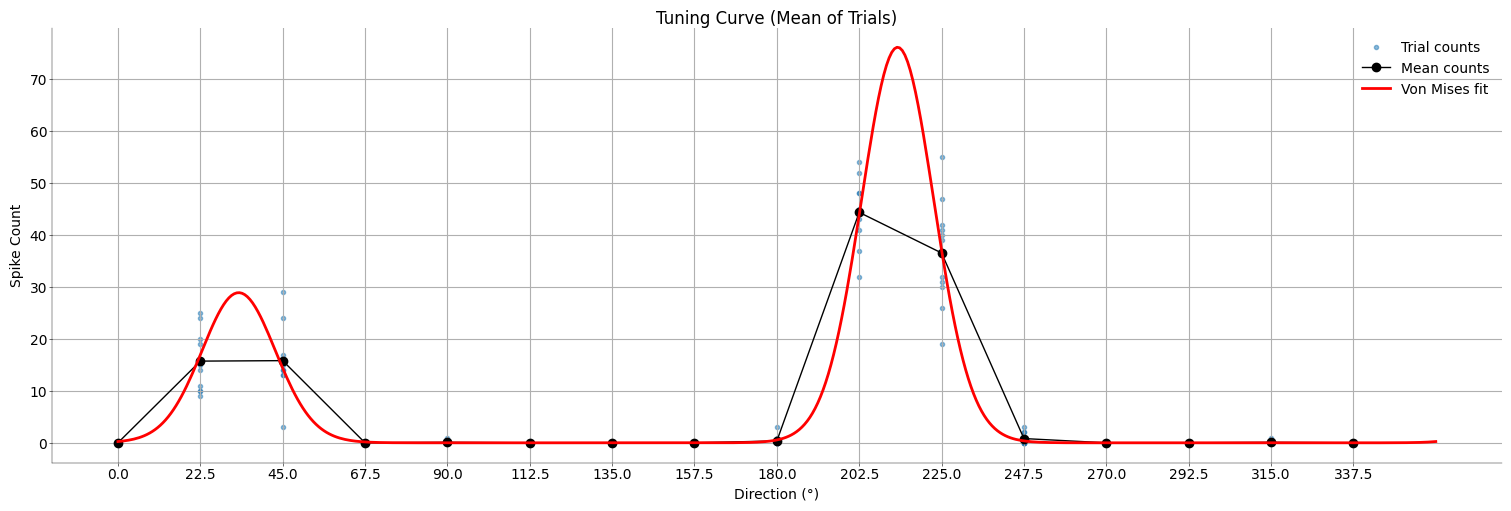

Neuron 29: α=4.33, κ=8.19, ν=0.48, ϕ=212.99°


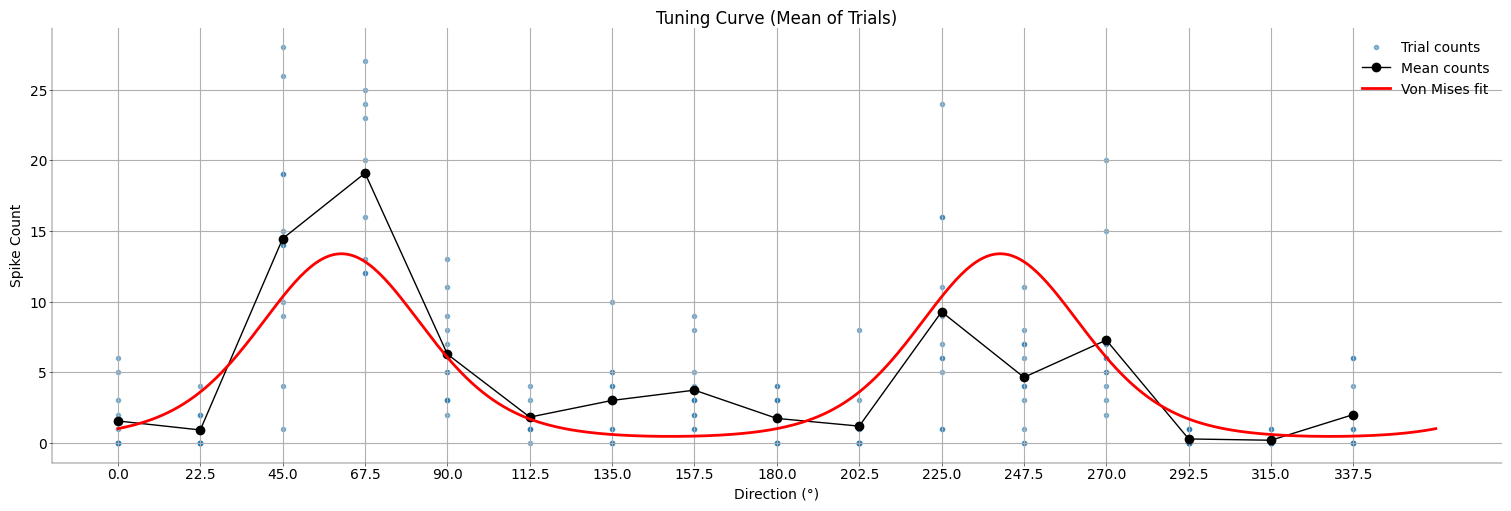

Neuron 37: α=2.59, κ=1.69, ν=0.00, ϕ=241.03°


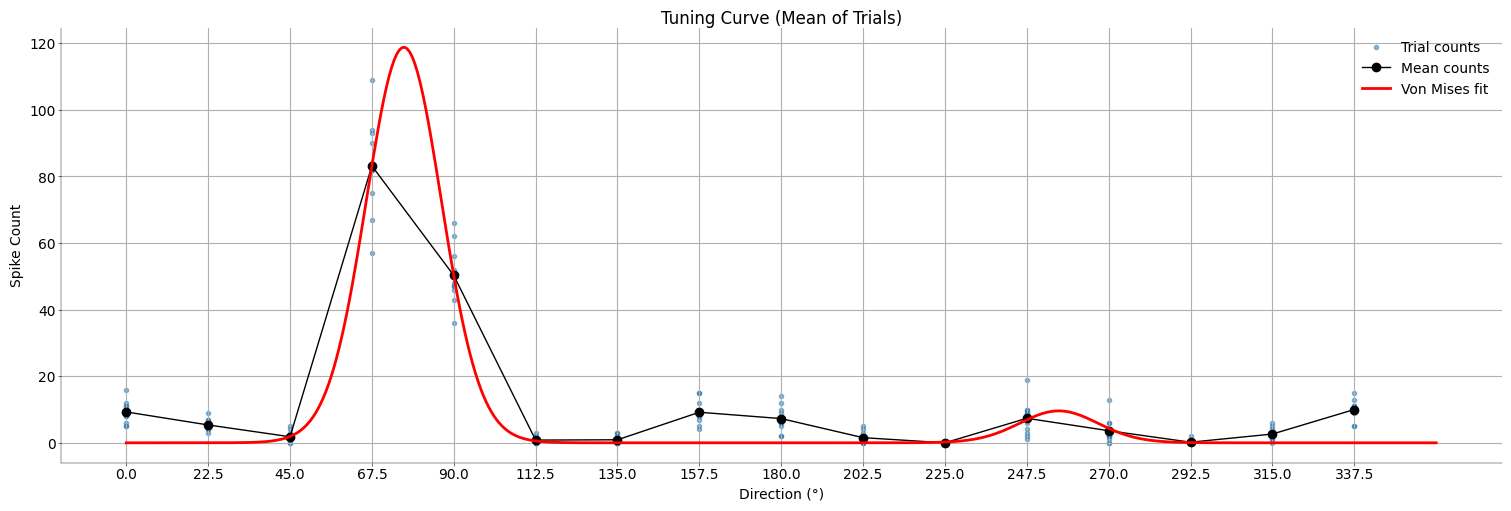

In [ ]:
# ----------------------------------------------------------
# plot the average number of spikes per direction, the spike
# counts from individual trials as well as your optimal fit
# for different neurons (0.5 pts)
# ----------------------------------------------------------

neurons = [28, 29, 37]

for neuron in neurons:
    dirs, counts = get_data(spikes, neuron)
    print(
        f"Neuron {neuron}: α={p_opt[0]:.2f}, κ={p_opt[1]:.2f}, ν={p_opt[2]:.2f}, ϕ={p_opt[3]:.2f}°"
    )
    p_opt = tuningCurve(counts, dirs, show=True)

## Task 4: Permutation test for direction tuning

Implement a permutation test to quantitatively assess whether a neuron is direction/orientation selective. To do so, project the vector of average spike counts, $m_k=\frac{1}{N}\sum_j x_{jk}$ on a complex exponential with two cycles, $v_k = \exp(\psi i \theta_k)$, where $\theta_k$ is the $k$-th direction of motion in radians and $\psi \in 1,2$ is the fourier component to test (1: direction, 2: orientation). Denote the projection by $q=m^Tv$. The magnitude $|q|$ tells you how much power there is in the $\psi$-th fourier component. 

Estimate the distribution of |q| under the null hypothesis that the neuron fires randomly across directions by running 1000 iterations where you repeat the same calculation as above but on a random permutation of the trials (that is, randomly shuffle the entries in the spike count matrix x). The fraction of iterations for which you obtain a value more extreme than what you observed in the data is your p-value. Implement this procedure in the function ```testTuning()```. 

Illustrate the test procedure for one of the cells from above. Plot the sampling distribution of |q| and indicate the value observed in the real data in your plot. 

How many cells are tuned at p < 0.01?

*Grading: 3 pts*


In [ ]:
def testTuning(
    counts: np.ndarray,
    dirs: np.ndarray,
    psi: int = 1,
    niters: int = 1000,
    show: bool = False,
    random_seed: int = 2046,
) -> Tuple[float, float, np.ndarray]:
    """Plot the data if show is True, otherwise just return the fit.

    Parameters
    ----------

    counts: np.array, shape=(total_n_trials, )
        the spike count during the stimulation period

    dirs: np.array, shape=(total_n_trials, )
        the stimulus direction in degrees

    psi: int
        fourier component to test (1 = direction, 2 = orientation)

    niters: int
        Number of iterations / permutation

    show: bool
        Plot or not.

    random_seed: int
        Random seed for reproducibility.

    Returns
    -------
    p: float
        p-value
    q: float
        magnitude of second Fourier component

    qdistr: np.array
        sampling distribution of |q| under the null hypothesis

    """
    
    # -------------------------------
    # calculate m, nu and q (0.5 pts)
    # -------------------------------

    # -------------------------------------------------------------------------
    # Estimate the distribution of q under the H0 and obtain the p value (1 pt)
    # -------------------------------------------------------------------------
    # ensure reproducibility using a random number generator
    # hint: access random functions of this generator
    rng = np.random.default_rng(random_seed)


    if show:
        # add plotting code here
        pass

Show null distribution for the example cell:

In [ ]:
# ---------------------------------------------------------
# Plot null distributions for example cells 28 & 29. (1 pt)
# ---------------------------------------------------------

Test all cells for orientation and direction tuning

In [ ]:
# --------------------------------------------------
# Test all cells for orientation / direction tuning. 
# Which ones are selective? (0.5 pts)
# --------------------------------------------------

Number of direction tuned neurons:

Number of orientation tuned neurons: